# Chemistry Feature Preprocessing and Dimensionality Reduction

# Install packages
Only run if you do not have these packages installed

In [ ]:
%pip install rdkit
%pip install pandas
%pip install scikit-learn
%pip install matplotlib

# Scaling and normalizing features
models will often perform better if features are scaled to a standard range. Sometimes normalization helps as well.
<br/>
Scikit-learn provides several tools for doing this, we will look at one here (but note that we import several, so feel free to try out others!). Does the scaling improve the model accuracy?

In [1]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, PowerTransformer, RobustScaler
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, DataStructs
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.svm import SVR

df = pd.read_csv("delaney.csv")

#let's calculate some molecular properties
#note how these will have very different ranges - molecular weights will be much larger than number of H bond donors
df["mol"] = df["SMILES"].apply(Chem.MolFromSmiles)
df["hba"] = df["mol"].apply(lambda m: Descriptors.NumHAcceptors(m) if m is not None else pd.NA)
df["hbd"] = df["mol"].apply(lambda m: Descriptors.NumHDonors(m) if m is not None else pd.NA)
df["mw"] = df["mol"].apply(lambda m: Descriptors.MolWt(m) if m is not None else pd.NA)
df["heteroatoms"] = df["mol"].apply(lambda m: Descriptors.NumHeteroatoms(m) if m is not None else pd.NA)
df["TPSA"] = df["mol"].apply(lambda m: Descriptors.TPSA(m) if m is not None else pd.NA)
df["fCSP3"] = df["mol"].apply(lambda m: Descriptors.FractionCSP3(m) if m is not None else pd.NA)

#split the training and test data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

#we can now try scaling the data, see above we have imported multiple scalers/transformers (see https://scikit-learn.org/stable/modules/preprocessing.html)
X_train = train_df[["hbd","hba","mw","heteroatoms","TPSA","fCSP3"]]
X_test = test_df[["hbd","hba","mw","heteroatoms","TPSA","fCSP3"]]
standard_scaler = StandardScaler()
#use fit_transform on X_train, then transform on X_test. Note you could also do fit on X_train, and then transform on both 
#test and train
X_train_std_scaled = standard_scaler.fit_transform(X_train)
X_test_std_scaled = standard_scaler.transform(X_test)

#now let's try out a SVM regression and see how test accuracy changes with and without scaling
svr_rbf = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)

svr_rbf.fit(X_train, train_df["measured log(solubility:mol/L)"])
predicted = svr_rbf.predict(X_test)
print("no scaling test MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"], predicted)))

svr_rbf = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)

svr_rbf.fit(X_train_std_scaled, train_df["measured log(solubility:mol/L)"])
predicted = svr_rbf.predict(X_test_std_scaled)
print("scaling test MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"], predicted)))

no scaling test MAE: 0.8859956706513531
scaling test MAE: 0.5595475778968223


# Dimensionality reduction
If we have too many parameters, we can get overfitting.
<br/>
One way to reduce parameters, is to reduce the number of features
<br/>
We can do this with dimensionality reduction techniques, such as principal component analaysis (PCA)
<br/>
Does this improve the accuracy? If it doesn't what are some possible reasons why?

In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2) #here we set how many dimensions we want to keep, try adjusting this and seeing how it affects accuracy
#we have 6 features, so we are reducing the dimensions from 6 to 2

#PCA works better with scaled or normalized data, so we will use our scaled data
X_train_pca = pca.fit_transform(X_train_std_scaled)
X_test_pca = pca.transform(X_test_std_scaled)

#explained variance tells us how well each dimension of the reduced data capture the variance of all data
#you ideally would capture most of the variance with your reduced representation
print("Explained Variance: ", pca.explained_variance_ratio_)

svr_rbf = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)

svr_rbf.fit(X_train_pca, train_df["measured log(solubility:mol/L)"])
predicted = svr_rbf.predict(X_test_pca)
print("With PCA MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"], predicted)))


Explained Variance:  [0.59727417 0.18051086]
With PCA MAE: 1.0876460995864679


# Plotting explained variance
Sometimes it can be useful to plot explained variance, this can help you choose which number of principal components to use

Text(0.5, 1.0, 'PCA Explained Variance')

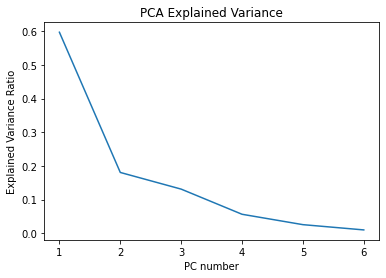

In [3]:
import matplotlib.pyplot as plt

# first let's run pca and keep all components, to do that we can not set n_components
pca = PCA()
X_train_pca = pca.fit_transform(X_train_std_scaled)

plt.figure()
plt.plot(range(1,len(pca.explained_variance_ratio_)+1),pca.explained_variance_ratio_)
plt.xlabel("PC number")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")

# Plotting data on PCs
It can be helpful to plot your data on the top 2 or 3 PCs to see if it separates by class (for classification) or shows a trend (for regression)

Text(0.5, 1.0, 'Solubility data plotted on top 2 PCs')

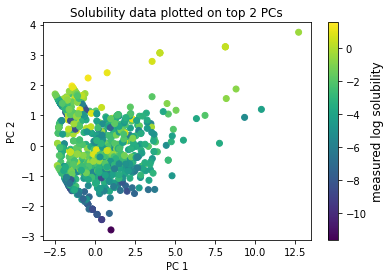

In [4]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std_scaled)
plt.figure()
#scatter plot with points colored by solubility
plt.scatter(X_train_pca[:,0],X_train_pca[:,1],c=train_df["measured log(solubility:mol/L)"], cmap='viridis')
#add a color bar legend
cbar = plt.colorbar()
cbar.set_label('measured log solubility', fontsize=12) # Label for your legend
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Solubility data plotted on top 2 PCs")

# Which features contribute to which PCs?
We can look at which features contribute to which PCs by looking at the size of the coefficients for that feature. This will help us interpret which of the original features the model actually ends up relying on the most when it makes its predictions. This can be visualized as a bar graph or in 2D for 2 PCs

Text(0.5, 0, 'feature')

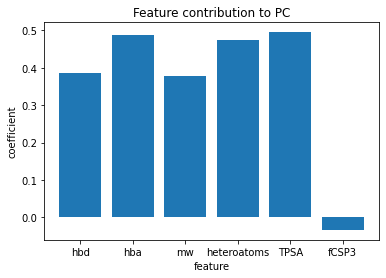

In [5]:
#plot bar for PC1, try chainging the code to look at PC2

#this gives us PC1
pc1 = pca.components_[0]
#this give us PC2
pc2 = pca.components_[1]

#we want labels for our original training features before PCA
features = ["hbd","hba","mw","heteroatoms","TPSA","fCSP3"]
plt.bar(features, pc1)
plt.title("Feature contribution to PC")
plt.ylabel("coefficient")
plt.xlabel("feature")

Text(0.5, 1.0, 'Loadings Plot')

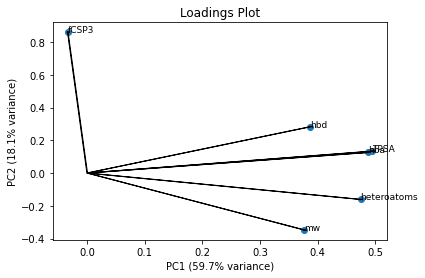

In [6]:
#plot the data
plt.scatter(pca.components_[0],pca.components_[1])
#add labels to the scatter points
for i in range(0, len(features)):
    plt.text(
        pca.components_[0,i],
        pca.components_[1,i],
        features[i],
        fontsize=9
    )
    plt.arrow(0,0,pca.components_[0,i],pca.components_[1,i])
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Loadings Plot")

# Pipelines
We can put all the steps of  scaling, PCA, and model together in a pipeline. This can reduce the number of lines of code we need and let us optimize hyperparameters across the pipeline.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


#assemble the pipeline, in this example we will use GridSearch to try different scalers
pipe = Pipeline([
    ("scaler", StandardScaler()),   # placeholder; will be swapped by grid search
    ("pca", PCA()),
    ("svr", SVR())
])

param_grid = {
    "scaler": [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler(),
        Normalizer()
    ],
    "pca__n_components": [3, 4, 6],
    "svr__kernel": ["linear", "rbf"],
} #note we could add more hyperparameters for the SVM regression, but to make this run faster, we will leave them out

#for regression we want to use negative mean squared error, because GridSearch tries to maximize values
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid.fit(X_train, train_df["measured log(solubility:mol/L)"])

print("Best parameters:")
print(grid.best_params_)

print("\nBest CV score (negative MSE):")
print(grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
print("optimized MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"], y_pred)))


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
{'pca__n_components': 6, 'scaler': StandardScaler(), 'svr__kernel': 'rbf'}

Best CV score (negative MSE):
-0.8882183152768708
optimized MAE: 0.6643376511826968
